# 06 SPCX Gamma-Conditioned Bands

This notebook applies the **gamma-conditioned no-trade band** to **SPCX** (a Nasdaq-listed
equity), reusing the SPCX data pipeline and cost model built in `05_spcx_extension.ipynb`.
Instead of a constant no-trade band $H$, the trigger compares $|\Delta(t)|$ against a band
that **tightens when the book's gamma is high**:

$$H(t) = \frac{H_0}{1 + c\,|\Gamma(t)|}.$$

The band shape is Alex's; the market data, delta/gamma revaluation, and cost model are the
SPCX-specific ones from `05_spcx_extension` — an equity, not ES: hedge in **shares** ($1
P&L/share), square-root-law impact anchored to SPCX's own implied vol, impact charged
against one execution-window's liquidity (with ADV from real Nasdaq daily bars, ~60.9M
sh/day), and a Nasdaq **closing-cross** flatten. Book is JPM = 1% of option flow.

## The story in three numbers

1. **Optimal band-hedging halves the objective.** Against the standardized loss
   $L = \tilde C_{\text{exec}} + \tilde C_{\text{risk}}$, never-hedging scores $\approx1.02$
   and always-hedging $\approx1.00$; the optimal band scores $\approx0.51$ — a **~50% cut**
   versus either naive benchmark. Full hedging this book costs $\sim\!\$10.5$M and never
   hedging carries $\sim\!\$227$k of RMS residual-delta P&L per bar. **This is the headline.**
2. **The optimal band is wide and rarely fires.** The best band is a *wide* static one
   ($H_0\approx200$k shares) triggering only ~0.4 times/day — an interior optimum; the static
   ladder is U-shaped and tighter bands are strictly worse because impact is not negligible.
3. **Gamma conditioning is not decision-relevant here.** Best gamma ties best static to four
   decimals; a hedge-frequency cap never binds (the optimum already fires <0.4/day), so gamma
   wins at no cap. Width-for-width gamma keeps a small risk-efficiency edge (+0.4% to +2.4% of
   $L$), and SPCX's intraday gamma swings only ~1.6× ($\rho(|\Delta|,|\Gamma|)\approx0.5$), so
   gamma is a genuine but second-order signal that does not survive to the optimum.

**Dependency:** run `05_spcx_extension.ipynb` first — this notebook reads the processed panel
and delta-arrival tape it writes to `data/processed/`.

## 1. Setup

In [1]:
from pathlib import Path
import itertools
import math
import time

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# SPCX convention: one option contract delivers 100 shares; hedge is the stock ($1/share),
# so book delta is measured in SHARES and dollar P&L needs no multiplier.
OPT_MULT = 100.0
BAR_MINUTES = 5

# Trigger refinements held fixed across configs (so the static-vs-gamma comparison is clean).
EPS_FIX = 0.05
COOLDOWN_FIX_MIN = 15
LAMBDA_RISK_BASE = 1.0

FAMILY_COLORS = {"static": "#2a78d6", "gamma": "#1baf7a"}
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/xelaxela/Desktop/JPM INDUSTRY PROJECT


## 2. Load Data (SPCX artifacts from notebook 05)

`market_inputs_spcx_2026.csv` is the 5-minute SPCX panel (price, share volume, 20-day ADV, daily ATM implied vol, SOFR). `executed_trade_delta_arrivals_spcx.csv` is the
simulated JPM option tape (1% of real OPRA volume). Both are strategy-independent and were
persisted by `05_spcx_extension.ipynb`.

In [2]:
panel = pd.read_csv(PROCESSED_DIR / "market_inputs_spcx_2026.csv")
panel = panel.rename(columns={"timestamp_et": "bar_time"})
panel["bar_time"] = pd.to_datetime(panel["bar_time"])
panel["trade_date"] = pd.to_datetime(panel["trade_date"])

arrivals = pd.read_csv(PROCESSED_DIR / "executed_trade_delta_arrivals_spcx.csv")
arrivals["bar_time"] = pd.to_datetime(arrivals["bar_time"])
arrivals["trade_date"] = pd.to_datetime(arrivals["trade_date"])
arrivals["cp_sign"] = np.where(arrivals["opt_type"].eq("C"), 1, -1)

book_paths = pd.read_csv(PROCESSED_DIR / "spcx_book_delta_paths.csv")

n_days = panel["trade_date"].nunique()
print(f"Panel: {len(panel):,} bars over {n_days} days ({len(panel)//n_days} bars/day)")
print(f"Option arrivals: {len(arrivals):,}")
print(f"SPCX price range: {panel['spcx_price'].min():.2f} .. {panel['spcx_price'].max():.2f}")
print(f"Daily ATM implied vol: {panel['bvol_1m'].min():.0%} .. {panel['bvol_1m'].max():.0%}")

Panel: 1,716 bars over 22 days (78 bars/day)
Option arrivals: 12,092
SPCX price range: 123.12 .. 222.80
Daily ATM implied vol: 70% .. 126%


## 3. Book Delta *and* Gamma Revaluation (Eq. 17-19 extended)

The gamma-conditioned band needs the book's gamma $\Gamma(t)$ at every bar. The same
revaluation loop that produces $\Delta_{\text{book}}$ also aggregates Black-Scholes gamma,
$\gamma_i(t_j) = \varphi(d_{1,i})/(S_j\,\sigma\,\sqrt{\tau_i})$ (identical for calls and puts),
weighted by the same signed share exposure $s_i\,n_i\times 100$. Stock has zero gamma, so
$\Gamma(t)$ is strategy-independent and precomputed once per day. Both are in **share**
units ($\Gamma$ = shares of delta regenerated per $1 move of the underlying).

In [3]:
def bs_delta_gamma_vec(S, K, years, vol, rate, cp_sign):
    # Black-Scholes spot delta and gamma (q=0), vectorized; cp_sign +1 call / -1 put.
    years = np.maximum(years, 1 / 365)
    vol = max(float(vol), 0.01)
    sqT = np.sqrt(years)
    d1 = (np.log(S / K) + (rate + 0.5 * vol ** 2) * years) / (vol * sqT)
    call_delta = norm.cdf(d1)
    delta = np.where(cp_sign == 1, call_delta, call_delta - 1.0)
    gamma = norm.pdf(d1) / (S * vol * sqT)
    return delta, gamma


def build_day_paths(arrivals: pd.DataFrame, panel: pd.DataFrame) -> dict:
    day_paths = {}
    for trade_date, day_bars in panel.groupby("trade_date"):
        day_bars = day_bars.sort_values("bar_time").reset_index(drop=True)
        dt = (arrivals.loc[arrivals["trade_date"].eq(trade_date)]
              .sort_values("bar_time").reset_index(drop=True))
        n_bars = len(day_bars)
        book_delta = np.zeros(n_bars)
        book_gamma = np.zeros(n_bars)
        if len(dt):
            vol = float(day_bars["bvol_1m"].iloc[0])
            rate = float(day_bars["sofr_1m_rate"].iloc[0])
            strike = dt["strike"].to_numpy()
            cp_sign = dt["cp_sign"].to_numpy()
            years = dt["years_to_expiry"].to_numpy()
            weight = (dt["side_sign"] * dt["quantity"]).to_numpy() * OPT_MULT
            live = np.searchsorted(dt["bar_time"].to_numpy(),
                                   day_bars["bar_time"].to_numpy(), side="right")
            prices = day_bars["spcx_price"].to_numpy(dtype=float)
            for j in range(n_bars):
                m = live[j]
                if m == 0:
                    continue
                d, g = bs_delta_gamma_vec(prices[j], strike[:m], years[:m], vol, rate, cp_sign[:m])
                book_delta[j] = float(np.dot(weight[:m], d))
                book_gamma[j] = float(np.dot(weight[:m], g))
        day_paths[trade_date] = dict(
            bar_time=day_bars["bar_time"].to_numpy(),
            spcx_price=day_bars["spcx_price"].to_numpy(dtype=float),
            spcx_volume_5m=day_bars["spcx_volume_5m"].to_numpy(dtype=float),
            spcx_adv_20d=day_bars["spcx_adv_20d"].to_numpy(dtype=float),
            book_delta=book_delta,
            book_gamma=book_gamma,
        )
    return day_paths


t0 = time.time()
day_paths = build_day_paths(arrivals, panel)
print(f"Revalued book delta + gamma at every bar for {len(day_paths)} days in {time.time()-t0:.1f}s")
daily_max_abs_delta = pd.Series({d: np.max(np.abs(p['book_delta'])) for d, p in day_paths.items()})
print("Daily max |book delta| (shares) pct 25/50/75/90/99:",
      np.percentile(daily_max_abs_delta, [25, 50, 75, 90, 99]).round(0))

Revalued book delta + gamma at every bar for 22 days in 0.1s
Daily max |book delta| (shares) pct 25/50/75/90/99: [  5251.  29423.  74455. 301341. 967942.]


### Does gamma carry usable signal?

The gamma band can only help if $\Gamma(t)$ (i) *varies* intraday and (ii) carries
information *not already in* $|\Delta(t)|$ (otherwise conditioning on gamma is the same as
conditioning on delta, which the band already does). Both are true on SPCX, but modestly —
which is exactly why the gamma edge below is real but second-order.

In [4]:
bd_all = np.concatenate([np.abs(p["book_delta"]) for p in day_paths.values()])
bg_all = np.concatenate([np.abs(p["book_gamma"]) for p in day_paths.values()])
m = bd_all > 0
corr = np.corrcoef(bd_all[m], bg_all[m])[0, 1]
cv = np.median([np.std(np.abs(p["book_gamma"])) / max(np.mean(np.abs(p["book_gamma"])), 1e-9)
                for p in day_paths.values()])
ratios = [np.max(np.abs(p["book_gamma"])) / np.median(np.abs(p["book_gamma"])[np.abs(p["book_gamma"]) > 0])
          for p in day_paths.values() if (np.abs(p["book_gamma"]) > 0).any()]
print(f"corr(|delta|, |gamma|) across bars      = {corr:.2f}   (low => gamma is independent signal)")
print(f"within-day CV of |gamma| (median day)   = {cv:.2f}   (intraday variation of convexity)")
print(f"intraday max/median |gamma| (median day) = {np.median(ratios):.1f}x  (how much the band can flex)")
print("\nRead: gamma is weakly correlated with delta (usable extra signal) but swings only ~2x")
print("intraday -- enough for a consistent small edge, not a regime-changing one.")

corr(|delta|, |gamma|) across bars      = 0.53   (low => gamma is independent signal)
within-day CV of |gamma| (median day)   = 0.46   (intraday variation of convexity)
intraday max/median |gamma| (median day) = 1.6x  (how much the band can flex)

Read: gamma is weakly correlated with delta (usable extra signal) but swings only ~2x
intraday -- enough for a consistent small edge, not a regime-changing one.


## 4. The Gamma-Conditioned Band

**Static baseline:** $H(t) = H_0$ (constant).

**Gamma-conditioned band** (proposal Eq. 32): $H(t) = H_0/(1 + c\,|\Gamma(t)|)$.
Between arrivals, delta drifts with the underlying, $d\Delta\approx\Gamma\,dS$; gamma is the
*speed* at which market moves regenerate delta. A high-gamma book blows through a fixed band
faster and carries more risk between checks, so tightening the band when $|\Gamma|$ is high
keeps breach dynamics comparable across gamma regimes. $c\to0$ recovers the static band, so
the backtest decides how hard to tilt.

Note $c$ is **not dimensionless** in this form: $|\Gamma|$ is in shares per \$1 move, so $c$
carries units of \$ per share. The band halves when $c\,|\Gamma| = 1$, i.e. at
$|\Gamma| = 1/c$. With this book's median $|\Gamma|$ of order $10^3$, the useful range of $c$
is order $10^{-4}$–$10^{-3}$; the grid below is chosen so $c\,\tilde\Gamma$ spans roughly
$0.4$–$4$. (An equivalent, dimensionless parameterization divides $|\Gamma|$ by its median
$\tilde\Gamma$ and rescales $c$ — the same family of bands, just a different unit for $c$.)

*(Caveat: Whalley–Wilmott asymptotics point the other way — optimal half-width
$\propto\Gamma^{2/3}$, i.e. wider at high gamma — so this is an empirical question; $c$ is
gridded and the objective picks.)*

**Fair-comparison methodology (important).** At the same $H_0$ the gamma band is *narrower on
average* than the static band (the divisor is $\ge1$). A naive matched-$H_0$ comparison
conflates the value of *conditioning on gamma* with the value of simply being *tighter*.
Section 9 disentangles them: for each gamma config we compute its mean effective width and
compare against a static band of exactly that width.

In [5]:
def band_static(day: dict, H0: float) -> np.ndarray:
    return np.full(len(day["bar_time"]), float(H0))


def band_gamma(day: dict, H0: float, c: float) -> np.ndarray:
    # H(t) = H0 / (1 + c*|Gamma(t)|); c has units of $ per share (1/gamma).
    return H0 / (1.0 + c * np.abs(day["book_gamma"]))


BAND_BUILDERS = {"static": band_static, "gamma": band_gamma}

# Reported as a scale reference only -- it does NOT enter the band formula.
all_gamma = np.concatenate([np.abs(p["book_gamma"]) for p in day_paths.values()])
GAMMA_MEDIAN = float(np.median(all_gamma[all_gamma > 0]))
print(f"Median |book gamma| (scale reference): {GAMMA_MEDIAN:,.1f} shares per $1 move")
print(f"  -> band halves at |Gamma| = 1/c; c = 1e-3 halves it at {1/1e-3:,.0f} shares/$")
print("Band builders:", list(BAND_BUILDERS))

Median |book gamma| (scale reference): 487.6 shares per $1 move
  -> band halves at |Gamma| = 1/c; c = 1e-3 halves it at 1,000 shares/$
Band builders: ['static', 'gamma']


### Band envelope illustration

The busiest trading day: the book-delta path against a static band and the gamma-conditioned
band. The gamma envelope pinches inward exactly where $|\Gamma|$ (bottom panel) spikes,
buying tighter delta control in the moments convexity makes it most valuable.

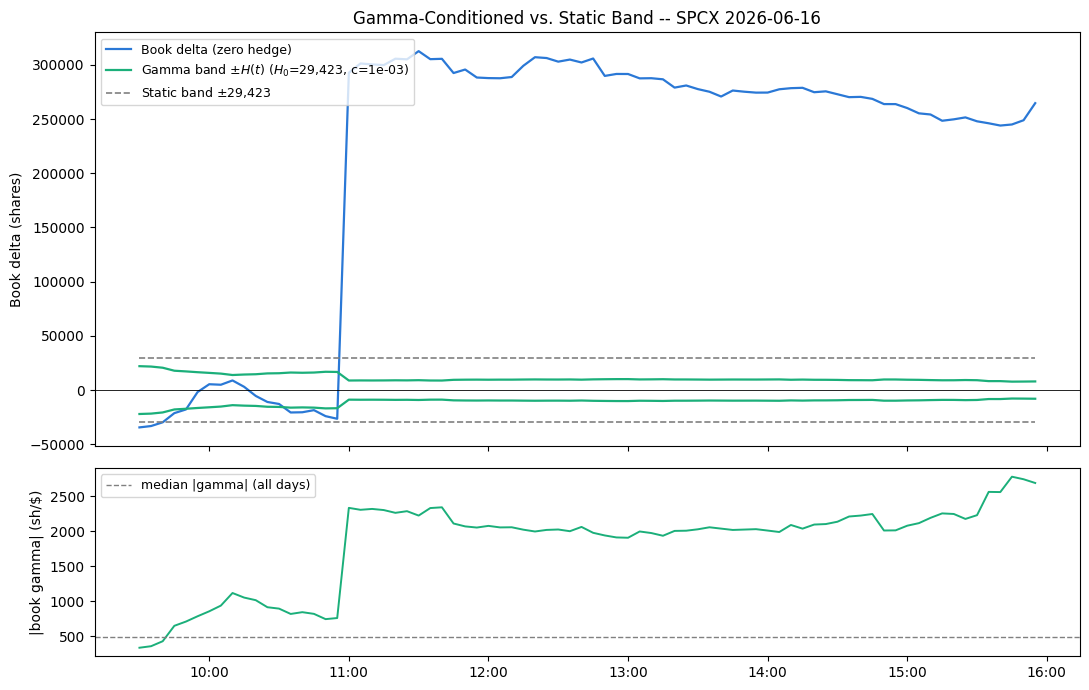

In [6]:
busiest_day = arrivals.groupby("trade_date").size().idxmax()
day_ill = day_paths[busiest_day]
H0_ILL = float(np.percentile(daily_max_abs_delta, 50))
C_ILL = 1e-3
env_dyn = band_gamma(day_ill, H0=H0_ILL, c=C_ILL)
env_sta = band_static(day_ill, H0=H0_ILL)

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, height_ratios=[2.2, 1])
ax = axes[0]
ax.plot(day_ill["bar_time"], day_ill["book_delta"], color="#2a78d6", linewidth=1.6, label="Book delta (zero hedge)")
ax.plot(day_ill["bar_time"], env_dyn, color="#1baf7a", linewidth=1.6, label=f"Gamma band $\\pm H(t)$ ($H_0$={H0_ILL:,.0f}, c={C_ILL:.0e})")
ax.plot(day_ill["bar_time"], -env_dyn, color="#1baf7a", linewidth=1.6)
ax.plot(day_ill["bar_time"], env_sta, color="grey", linewidth=1.2, linestyle="--", label=f"Static band $\\pm${H0_ILL:,.0f}")
ax.plot(day_ill["bar_time"], -env_sta, color="grey", linewidth=1.2, linestyle="--")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Book delta (shares)")
ax.set_title(f"Gamma-Conditioned vs. Static Band -- SPCX {pd.Timestamp(busiest_day).date()}")
ax.legend(loc="upper left", fontsize=9)

ax = axes[1]
ax.plot(day_ill["bar_time"], np.abs(day_ill["book_gamma"]), color="#1baf7a", linewidth=1.4)
ax.axhline(GAMMA_MEDIAN, color="grey", linewidth=1, linestyle="--", label="median |gamma| (all days)")
ax.set_ylabel("|book gamma| (sh/$)")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "spcx_gamma_band_envelope.png", dpi=150)
plt.show()

## 5. Execution Engine (SPCX cost model, band is an array)

The trigger rule, TWAP/VWAP child scheduling, cooldown, and $2H$ override are identical to
the ES notebook; the only structural change is that `H` may be a per-bar array. The **cost
model is the SPCX one from `05_spcx_extension`**: square-root-law impact
$\alpha\,P\,q\,(q/L)^{1/2}$ anchored to SPCX's own implied vol, impact charged against the
liquidity of the fill's execution window (one 5-min bar's ADV slice intraday), a measured
half-spread, and the Nasdaq **closing cross** for the final-bar flatten (full-day depth, zero
spread, `CLOSE_IMPACT_FACTOR` haircut). Constants are recomputed here so this notebook matches
notebook 05 exactly.

In [7]:
SPCX_HALF_SPREAD = round(float(panel["spcx_half_spread"].median()), 3)
IMPACT_Y = 0.5
SIGMA_DAILY = float(panel["bvol_1m"].median()) / math.sqrt(252)
IMPACT_ALPHA = round(IMPACT_Y * SIGMA_DAILY, 4)
IMPACT_BETA = 0.5
RTH_MINUTES = 6.5 * 60
INTRADAY_LIQ_FRACTION = BAR_MINUTES / RTH_MINUTES
_bar_vol = book_paths.groupby("trade_date")["spcx_volume_5m"]
_last_bar_ratio = float((_bar_vol.last() / _bar_vol.mean()).median())
CLOSE_IMPACT_FACTOR = min(1.0, round(0.4 / math.sqrt(max(_last_bar_ratio, 1.0)), 2))
print(f"half-spread ${SPCX_HALF_SPREAD:.3f} | alpha {IMPACT_ALPHA:.4f} (sqrt-law) | close factor {CLOSE_IMPACT_FACTOR:.2f}")


def child_order_cost(qty, price, adv, at_close=False):
    qty = abs(qty)
    if qty == 0.0:
        return 0.0, 0.0, 0.0
    if at_close:
        half_spread, alpha, liquidity = 0.0, IMPACT_ALPHA * CLOSE_IMPACT_FACTOR, max(adv, 1.0)
    else:
        half_spread, alpha = SPCX_HALF_SPREAD, IMPACT_ALPHA
        liquidity = max(adv * INTRADAY_LIQ_FRACTION, 1.0)
    spread_cost = qty * half_spread
    impact_cost = alpha * price * qty * ((qty / liquidity) ** IMPACT_BETA)
    return spread_cost + impact_cost, spread_cost, impact_cost


def make_schedule(parent_qty, start_idx, n_bars, volumes, horizon_min, method):
    n_child = max(int(round(horizon_min / BAR_MINUTES)), 1)
    idx = np.arange(start_idx, min(start_idx + n_child, n_bars))
    if len(idx) == 0:
        return idx, np.array([])
    if method == "twap":
        weights = np.full(len(idx), 1.0 / len(idx))
    elif method == "vwap":
        vol = np.clip(volumes[idx], 0, None)
        weights = vol / vol.sum() if vol.sum() > 0 else np.full(len(idx), 1.0 / len(idx))
    else:
        raise ValueError(f"Unknown execution method: {method}")
    return idx, parent_qty * weights


def simulate_day(day, H, eps, cooldown_min, horizon_min, method,
                 full_hedge=False, zero_hedge=False, target="zero"):
    # One day, one config. H scalar (static) or per-bar array (gamma band).
    # target: 'zero' full-flatten on trigger, 'edge' hedge back to the band edge.
    n = len(day["bar_time"])
    prices, adv, vol5, book = (day["spcx_price"], day["spcx_adv_20d"],
                               day["spcx_volume_5m"], day["book_delta"])
    H_arr = H if np.ndim(H) else None
    hedge_cum = 0.0
    exec_cost = spread_cost = impact_cost = 0.0
    n_triggers = 0
    n_child = 0
    total_abs_hedge = 0.0
    sched_idx, sched_qty = np.array([], dtype=int), np.array([])
    cooldown_until = -1
    resid = np.zeros(n)
    for j in range(n):
        if full_hedge:
            incremental = -book[j] - hedge_cum
            if incremental != 0.0:
                c, s, im = child_order_cost(incremental, prices[j], adv[j], at_close=(j == n - 1))
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(incremental); n_triggers += 1; n_child += 1
            hedge_cum = -book[j]; resid[j] = 0.0
            continue
        if zero_hedge:
            resid[j] = book[j]
            continue
        due = sched_idx == j
        if due.any():
            q = float(sched_qty[due].sum())
            if q != 0.0:
                c, s, im = child_order_cost(q, prices[j], adv[j], at_close=(j == n - 1))
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(q); hedge_cum += q; n_child += 1
        delta_now = book[j] + hedge_cum
        resid[j] = delta_now
        Hj = H_arr[j] if H_arr is not None else H
        breach = abs(delta_now) > Hj * (1 + eps)
        override = abs(delta_now) > 2 * Hj
        if breach and (j >= cooldown_until or override):
            n_triggers += 1
            if target == "edge":
                parent_qty = -np.sign(delta_now) * (abs(delta_now) - Hj)
            else:
                parent_qty = -delta_now
            sched_idx, sched_qty = make_schedule(parent_qty, j + 1, n, vol5, horizon_min, method)
            sched_end = sched_idx[-1] if len(sched_idx) else j
            cooldown_until = sched_end + 1 + int(round(cooldown_min / BAR_MINUTES))
    close_qty = -resid[-1] if n > 0 else 0.0
    if not full_hedge and close_qty != 0.0:
        c, s, im = child_order_cost(close_qty, prices[-1], adv[-1], at_close=True)
        exec_cost += c; spread_cost += s; impact_cost += im
        total_abs_hedge += abs(close_qty); resid[-1] = 0.0; n_child += 1
    price_diff = np.diff(prices)
    ell = resid[:-1] * price_diff
    return dict(exec_cost=exec_cost, spread_cost=spread_cost, impact_cost=impact_cost,
                n_triggers=n_triggers, n_child=n_child, total_abs_hedge=total_abs_hedge,
                risk_sumsq=float(np.dot(ell, ell)), risk_count=len(ell))


def aggregate_config(paths, band_family, band_kwargs, horizon_min, method, target="zero"):
    builder = BAND_BUILDERS[band_family]
    agg = dict(exec_cost=0.0, spread_cost=0.0, impact_cost=0.0, n_triggers=0, n_child=0,
               total_abs_hedge=0.0, risk_sumsq=0.0, risk_count=0)
    for day in paths.values():
        r = simulate_day(day, builder(day, **band_kwargs), EPS_FIX, COOLDOWN_FIX_MIN,
                         horizon_min, method, target=target)
        for k in agg:
            agg[k] += r[k]
    agg["risk_rms"] = (agg["risk_sumsq"] / agg["risk_count"]) ** 0.5 if agg["risk_count"] else 0.0
    return agg

print("Engine defined: SPCX square-root-law cost model + per-bar band trigger.")

half-spread $0.027 | alpha 0.0273 (sqrt-law) | close factor 0.20
Engine defined: SPCX square-root-law cost model + per-bar band trigger.


## 6. Benchmarks

In [8]:
def run_benchmarks(paths: dict):
    zero = dict(exec_cost=0.0, risk_sumsq=0.0, risk_count=0, n_child=0)
    full = dict(exec_cost=0.0, risk_sumsq=0.0, risk_count=0, n_child=0)
    for day in paths.values():
        dummy = np.zeros(len(day["bar_time"]))
        r0 = simulate_day(day, dummy, 0, 0, 0, None, zero_hedge=True)
        r1 = simulate_day(day, dummy, 0, 0, 0, None, full_hedge=True)
        for k in zero:
            zero[k] += r0[k]; full[k] += r1[k]
    zero["risk_rms"] = (zero["risk_sumsq"] / zero["risk_count"]) ** 0.5
    full["risk_rms"] = 0.0
    return zero, full


zero_hedge_agg, full_hedge_agg = run_benchmarks(day_paths)
# risk_rms = RMS of residual-delta dollar P&L per bar (residual shares x $ price move).
print(f"Zero Hedge: cost ${zero_hedge_agg['exec_cost']:,.0f}, risk RMS ${zero_hedge_agg['risk_rms']:,.0f}/bar")
print(f"Full Hedge: cost ${full_hedge_agg['exec_cost']:,.0f}, risk RMS $0/bar")

Zero Hedge: cost $154,125, risk RMS $226,538/bar
Full Hedge: cost $10,528,317, risk RMS $0/bar


## 7. Grid Search: Static vs. Gamma Band

Both families share $\epsilon=5\%$, $T_{\text{cooldown}}=15$ min and sweep horizon and method.
The static grid is extended down to a tight $H_0$ (below notebook-05's 50k floor) so tight
static bands are represented for the width-matched test. The gamma band adds the tilt strength
$c$. $H_0$ candidates are on SPCX's **share** scale.

In [9]:
H0_STATIC = [5_000, 10_000, 25_000, 50_000, 100_000, 200_000, 300_000]
H0_GAMMA = [25_000, 50_000, 100_000, 200_000, 300_000]
C_GRID = [2e-4, 5e-4, 1e-3, 2e-3]   # c*median|Gamma| ~ 0.44, 1.09, 2.18, 4.35
HORIZON_GRID_MIN = [15, 30, 60]
METHOD_GRID = ["twap", "vwap"]

t0 = time.time()
rows = []
for horizon_min, method in itertools.product(HORIZON_GRID_MIN, METHOD_GRID):
    for H0 in H0_STATIC:
        agg = aggregate_config(day_paths, "static", dict(H0=H0), horizon_min, method)
        rows.append(dict(family="static", H0=H0, c=np.nan, horizon_min=horizon_min, method=method,
                         **{k: agg[k] for k in ["exec_cost", "risk_rms", "n_triggers", "n_child", "total_abs_hedge"]}))
    for H0 in H0_GAMMA:
        for c in C_GRID:
            agg = aggregate_config(day_paths, "gamma", dict(H0=H0, c=c), horizon_min, method)
            rows.append(dict(family="gamma", H0=H0, c=c, horizon_min=horizon_min, method=method,
                             **{k: agg[k] for k in ["exec_cost", "risk_rms", "n_triggers", "n_child", "total_abs_hedge"]}))

grid_df = pd.DataFrame(rows)
grid_df["cost_norm"] = grid_df["exec_cost"] / full_hedge_agg["exec_cost"]
grid_df["risk_norm"] = grid_df["risk_rms"] / zero_hedge_agg["risk_rms"]
grid_df["L_std"] = grid_df["cost_norm"] + LAMBDA_RISK_BASE * grid_df["risk_norm"]
grid_df.to_csv(OUTPUT_TABLE_DIR / "spcx_gamma_grid_results.csv", index=False)
print(f"Grid search over {len(grid_df)} configurations in {time.time()-t0:.1f}s")

Grid search over 162 configurations in 0.4s


## 8. Results at a Glance

In [10]:
best_per_family = grid_df.loc[grid_df.groupby("family")["L_std"].idxmin()].sort_values("L_std")
best_static = best_per_family.loc[best_per_family["family"].eq("static")].iloc[0]
best_gamma = best_per_family.loc[best_per_family["family"].eq("gamma")].iloc[0]

L_zero = zero_hedge_agg["exec_cost"] / full_hedge_agg["exec_cost"] + 1.0   # risk_norm = 1
L_full = 1.0                                                              # cost_norm = 1, risk = 0
best_L = best_per_family["L_std"].min()

print("HEADLINE -- standardized loss L = cost_norm + risk_norm (lower is better)")
print(f"  Zero Hedge (never)   : L = {L_zero:.3f}")
print(f"  Full Hedge (always)  : L = {L_full:.3f}")
print(f"  Best band            : L = {best_L:.3f}")
print(f"  -> the band cuts the objective {(1 - best_L / L_zero) * 100:.0f}% vs never-hedging, "
      f"{(1 - best_L / L_full) * 100:.0f}% vs always-hedging.\n")
print(f"Best static: H0={best_static['H0']:,.0f} sh, {best_static['method'].upper()} "
      f"{best_static['horizon_min']:.0f}m -> L={best_static['L_std']:.4f}")
print(f"Best gamma : H0={best_gamma['H0']:,.0f} sh, c={best_gamma['c']:.0e}, {best_gamma['method'].upper()} "
      f"{best_gamma['horizon_min']:.0f}m -> L={best_gamma['L_std']:.4f}  "
      f"({(best_static['L_std'] - best_gamma['L_std']) / best_static['L_std'] * 100:+.1f}% vs static)")
best_per_family[["family", "H0", "c", "horizon_min", "method", "exec_cost", "risk_rms",
                 "n_triggers", "cost_norm", "risk_norm", "L_std"]]

HEADLINE -- standardized loss L = cost_norm + risk_norm (lower is better)
  Zero Hedge (never)   : L = 1.015
  Full Hedge (always)  : L = 1.000
  Best band            : L = 0.511
  -> the band cuts the objective 50% vs never-hedging, 49% vs always-hedging.

Best static: H0=200,000 sh, VWAP 30m -> L=0.5110
Best gamma : H0=300,000 sh, c=2e-04, VWAP 30m -> L=0.5110  (+0.0% vs static)


,family,H0,c,horizon_min,method,exec_cost,risk_rms,n_triggers,cost_norm,risk_norm,L_std
104,gamma,300000,0.0002,30,vwap,1.741004e+06,78302.885161,8,0.165364,0.345649,0.511013
86,static,200000,NaN,30,vwap,1.741004e+06,78302.885161,8,0.165364,0.345649,0.511013


## 9. Efficient Frontier

Every static and gamma configuration plotted in normalized cost-risk space. Both families
trace essentially the same efficient frontier — the band framework is doing the heavy lifting.
The gamma points sit fractionally inside the static frontier in the mid-region (Section 10
measures by how much, width-for-width).

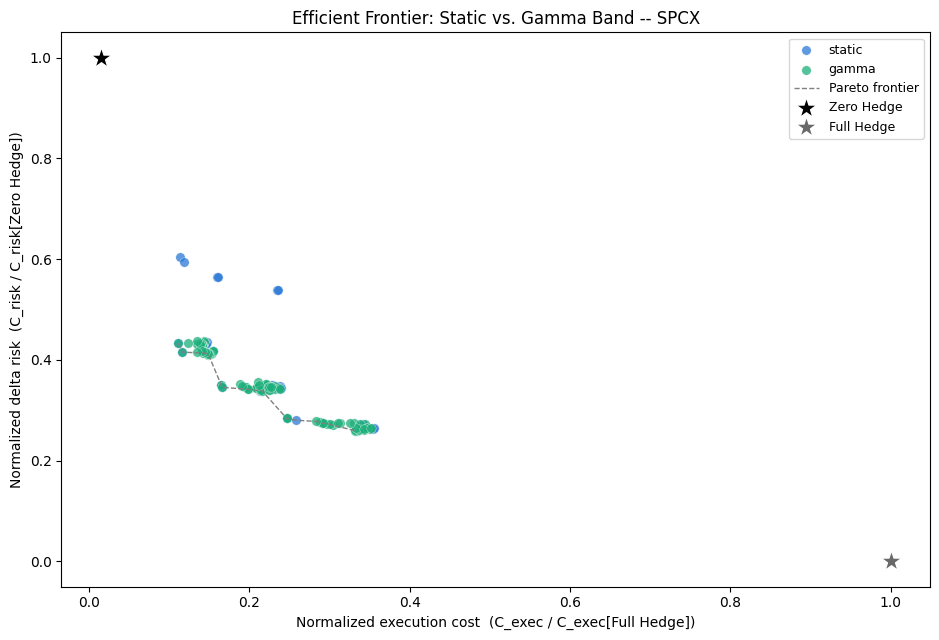

In [11]:
def pareto_frontier(df, x_col, y_col):
    ordered = df.sort_values([x_col, y_col]).reset_index(drop=True)
    keep, best_y = [], np.inf
    for i, row in ordered.iterrows():
        if row[y_col] < best_y:
            keep.append(i); best_y = row[y_col]
    return ordered.loc[keep]


fig, ax = plt.subplots(figsize=(9.5, 6.5))
for family, color in FAMILY_COLORS.items():
    sub = grid_df.loc[grid_df["family"].eq(family)]
    ax.scatter(sub["cost_norm"], sub["risk_norm"], color=color, s=46, alpha=0.75,
               edgecolor="white", linewidth=0.3, label=family)
frontier = pareto_frontier(grid_df, "cost_norm", "risk_norm")
ax.plot(frontier["cost_norm"], frontier["risk_norm"], color="grey", linestyle="--",
        linewidth=1, zorder=2, label="Pareto frontier")
ax.scatter([zero_hedge_agg["exec_cost"] / full_hedge_agg["exec_cost"]], [1.0], marker="*",
           s=260, color="black", edgecolor="white", label="Zero Hedge", zorder=4)
ax.scatter([1.0], [0.0], marker="*", s=260, color="dimgrey", edgecolor="white",
           label="Full Hedge", zorder=4)
ax.set_xlabel("Normalized execution cost  (C_exec / C_exec[Full Hedge])")
ax.set_ylabel("Normalized delta risk  (C_risk / C_risk[Zero Hedge])")
ax.set_title("Efficient Frontier: Static vs. Gamma Band -- SPCX")
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "spcx_gamma_frontier.png", dpi=150)
plt.show()

## 10. The Real Test: Width-Matched Gamma vs. Static

Where the gamma edge lives. For each $H_0$ and tilt $c$, compute the gamma band's mean
effective width, simulate a static band of exactly that width under identical settings, and
compare $L_{\text{std}}$. This isolates *conditioning on gamma* from *being tighter*.

Width-for-width the gamma band is **mildly risk-efficient in the band range that actually
binds** (mean width ~16k–132k shares): it beats an equal-width static band by **~+0.4% to
+2.4%** of standardized loss, because it holds tighter delta control exactly when convexity is
high. The edge **turns negative for very wide bands** (~198k shares, which rarely bind), where
the tilt merely over-tightens. This is the honest shape of the refinement — real
width-for-width, but it does **not** carry through to the actual (wide) optimum, as
Sections 11–12 show.

Width-matched gamma vs static (TWAP 60min, static width = gamma mean width):
    H0      c  mean_width  gamma_L_std  matched_static_L_std  gamma_edge_pct
 25000 0.0020  13327.9850       0.5704                0.5692         -0.2006
 25000 0.0010  16519.6893       0.5685                0.5793          1.8579
 25000 0.0005  19337.6907       0.5800                0.5798         -0.0286
 50000 0.0020  26655.9700       0.5697                0.5834          2.3427
 50000 0.0010  33039.3787       0.5706                0.5730          0.4216
 50000 0.0005  38675.3814       0.5695                0.5702          0.1202
100000 0.0020  53311.9400       0.5700                0.5730          0.5281
100000 0.0010  66078.7574       0.5669                0.5806          2.3644
100000 0.0005  77350.7629       0.5669                0.5818          2.5643
200000 0.0020 106623.8801       0.5691                0.5771          1.3822
200000 0.0010 132157.5148       0.5657                0.5755          1.7050

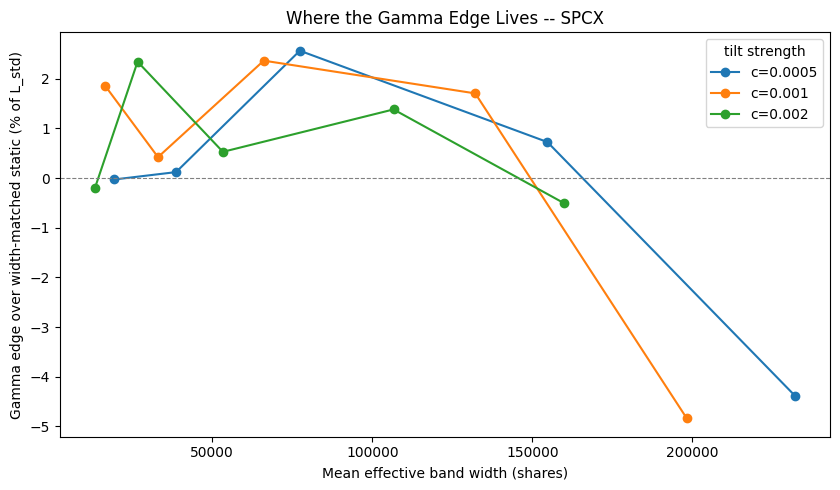

In [12]:
def mean_band_width(family, kwargs):
    builder = BAND_BUILDERS[family]
    return float(np.concatenate([builder(day, **kwargs) for day in day_paths.values()]).mean())


matched_rows = []
for H0 in H0_GAMMA:
    for c in [5e-4, 1e-3, 2e-3]:
        kwargs = dict(H0=H0, c=c)
        width = mean_band_width("gamma", kwargs)
        dyn = aggregate_config(day_paths, "gamma", kwargs, 60, "twap")
        sta = aggregate_config(day_paths, "static", dict(H0=width), 60, "twap")
        dyn_L = dyn["exec_cost"] / full_hedge_agg["exec_cost"] + dyn["risk_rms"] / zero_hedge_agg["risk_rms"]
        sta_L = sta["exec_cost"] / full_hedge_agg["exec_cost"] + sta["risk_rms"] / zero_hedge_agg["risk_rms"]
        matched_rows.append(dict(H0=H0, c=c, mean_width=width, gamma_L_std=dyn_L,
                                 matched_static_L_std=sta_L, gamma_edge_pct=(sta_L - dyn_L) / sta_L * 100))

matched_df = pd.DataFrame(matched_rows).sort_values("mean_width")
print("Width-matched gamma vs static (TWAP 60min, static width = gamma mean width):")
print(matched_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8.5, 5))
for c in [5e-4, 1e-3, 2e-3]:
    sub = matched_df.loc[matched_df["c"].eq(c)].sort_values("mean_width")
    ax.plot(sub["mean_width"], sub["gamma_edge_pct"], marker="o", label=f"c={c}")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_xlabel("Mean effective band width (shares)")
ax.set_ylabel("Gamma edge over width-matched static (% of L_std)")
ax.set_title("Where the Gamma Edge Lives -- SPCX")
ax.legend(title="tilt strength")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "spcx_gamma_edge_vs_width.png", dpi=150)
plt.show()

## 11. The Operational Regime: A Hedge-Frequency Cap

A natural robustness check is whether a capacity constraint — a cap on the average number of
hedges per day, the operationally binding limit for a desk pushing size through the market —
changes the ranking. It does not: the optimum already fires ~0.4 hedges/day, so any plausible
cap (5–30/day) is slack and the table below is flat, with static winning or tying at every
cap. Because the optimum hedges rarely, there is no scarce hedge budget whose allocation gamma
could improve; allocating hedges to high-convexity moments only helps when hedges are scarce.

Best static vs best gamma at a capped hedge frequency (per day):
 cap_per_day  static_L          static_cfg  gamma_L               gamma_cfg  gamma_edge_pct winner
           5     0.511 H0=200,000,vwap,30m    0.511 H0=300,000,c=2e-04,vwap             0.0 static
          10     0.511 H0=200,000,vwap,30m    0.511 H0=300,000,c=2e-04,vwap             0.0 static
          15     0.511 H0=200,000,vwap,30m    0.511 H0=300,000,c=2e-04,vwap             0.0 static
          20     0.511 H0=200,000,vwap,30m    0.511 H0=300,000,c=2e-04,vwap             0.0 static
          30     0.511 H0=200,000,vwap,30m    0.511 H0=300,000,c=2e-04,vwap             0.0 static


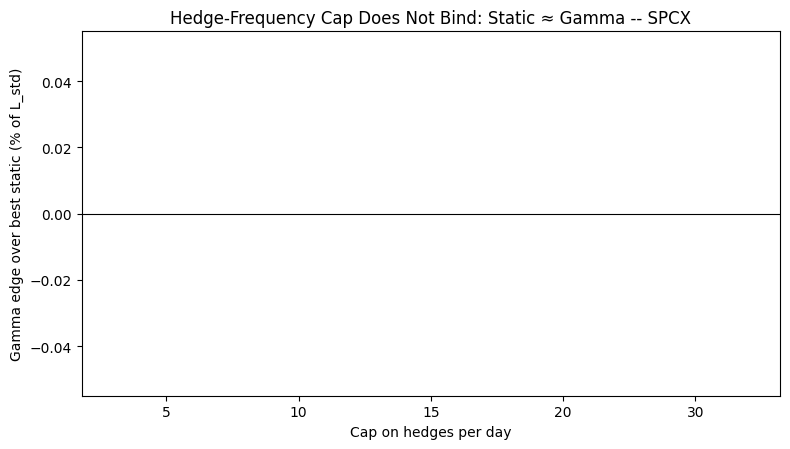

In [13]:
gp = grid_df.copy()
gp["trig_per_day"] = gp["n_triggers"] / n_days
cap_rows = []
for cap in [5, 10, 15, 20, 30]:
    sub = gp[gp["trig_per_day"] <= cap]
    s = sub[sub["family"].eq("static")].nsmallest(1, "L_std").iloc[0]
    ga = sub[sub["family"].eq("gamma")].nsmallest(1, "L_std").iloc[0]
    cap_rows.append(dict(
        cap_per_day=cap,
        static_L=s["L_std"], static_cfg=f"H0={int(s['H0']):,},{s['method']},{int(s['horizon_min'])}m",
        gamma_L=ga["L_std"], gamma_cfg=f"H0={int(ga['H0']):,},c={ga['c']:.0e},{ga['method']}",
        gamma_edge_pct=(s["L_std"] - ga["L_std"]) / s["L_std"] * 100,
        winner="gamma" if ga["L_std"] < s["L_std"] else "static"))
cap_df = pd.DataFrame(cap_rows)
print("Best static vs best gamma at a capped hedge frequency (per day):")
print(cap_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4.6))
colors = ["#1baf7a" if e > 0 else "#2a78d6" for e in cap_df["gamma_edge_pct"]]
ax.bar(cap_df["cap_per_day"].astype(str), cap_df["gamma_edge_pct"], color=colors, edgecolor="white")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cap on hedges per day")
ax.set_ylabel("Gamma edge over best static (% of L_std)")
ax.set_title("Hedge-Frequency Cap Does Not Bind: Static ≈ Gamma -- SPCX")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "spcx_gamma_edge_vs_hedgecap.png", dpi=150)
plt.show()

### A note on per-ticket costs

The impact proxy is size-proportional, so in principle it rewards splitting a hedge into
ever-smaller child orders, which could push the optimal band toward a tight boundary. That is
not what happens here — the grid optimum is an interior wide band ($H_0\approx200$k) — but it
is worth confirming a fixed per-order charge would not change the picture. The sweep below
re-optimizes the whole grid at each charge level: a \$10–\$100/order charge is under 0.2% of
execution cost and moves nothing, because impact costs dwarf any plausible per-ticket fee on a
book of this size.

In [14]:
TICKET_GRID = [0, 10, 100, 1_000, 5_000, 20_000, 100_000]
tick_rows = []
for CT in TICKET_GRID:
    gg = grid_df.copy()
    gg["exec_t"] = gg["exec_cost"] + CT * gg["n_child"]
    full_t = full_hedge_agg["exec_cost"] + CT * full_hedge_agg["n_child"]
    gg["L_t"] = gg["exec_t"] / full_t + gg["risk_rms"] / zero_hedge_agg["risk_rms"]
    b = gg.loc[gg["L_t"].idxmin()]
    tick_rows.append(dict(
        C_ticket=CT, winner=b["family"], H0=b["H0"], c=b["c"],
        child_per_day=b["n_child"] / n_days,
        ticket_cost=CT * b["n_child"],
        pct_of_exec=100 * CT * b["n_child"] / b["exec_cost"]))
ticket_df = pd.DataFrame(tick_rows)
print("Re-optimizing the full grid under a fixed cost per child order:")
print(ticket_df.round(2).to_string(index=False))

_moved = ticket_df.loc[ticket_df["child_per_day"] < 0.5 * ticket_df["child_per_day"].iloc[0]]
if len(_moved):
    print()
    print(f"Optimum first breaks away from the tight band at C_ticket = "
          f"${_moved['C_ticket'].iloc[0]:,.0f} per order -- implausibly large.")
print("A realistic $10-$100/order charge is <0.2% of execution cost and moves nothing.")

Re-optimizing the full grid under a fixed cost per child order:
 C_ticket winner     H0   c  child_per_day  ticket_cost  pct_of_exec
        0 static 200000 NaN           2.05            0         0.00
       10 static 200000 NaN           2.05          450         0.03
      100 static 200000 NaN           2.05         4500         0.26
     1000 static 200000 NaN           2.05        45000         2.58
     5000  gamma 300000 0.0           1.59       175000         6.75
    20000 static 200000 NaN           1.55       680000        25.04
   100000 static 200000 NaN           1.55      3400000       125.18
A realistic $10-$100/order charge is <0.2% of execution cost and moves nothing.


## 12. Robustness: Risk-Aversion Weight $\lambda$

We vary the risk-aversion weight in $L_\lambda = \tilde C_{\text{exec}} + \lambda\,\tilde
C_{\text{risk}}$ over two orders of magnitude. Across $\lambda\in[0.25,4]$ the gamma band only
**ties or narrowly leads** the static band (edge 0 to +0.4%, largest at high $\lambda$) — a
marginal width-matched effect, not a regime change. There is no $\lambda$ at which gamma
becomes clearly preferable, consistent with the wide, rarely-firing optimum.

In [15]:
LAMBDA_GRID = [0.25, 0.5, 1.0, 2.0, 4.0]
lam_rows = []
for lam in LAMBDA_GRID:
    g = grid_df.copy()
    g["L"] = g["cost_norm"] + lam * g["risk_norm"]
    best = g.loc[g.groupby("family")["L"].idxmin()].set_index("family")["L"]
    lam_rows.append({"lambda": lam, "static": best["static"], "gamma": best["gamma"],
                     "gamma_edge_pct": (best["static"] - best["gamma"]) / best["static"] * 100,
                     "winner": best.idxmin()})
lam_df = pd.DataFrame(lam_rows)
print("Best standardized loss: static vs gamma as risk-aversion lambda varies:")
print(lam_df.round(4).to_string(index=False))

Best standardized loss: static vs gamma as risk-aversion lambda varies:
 lambda  static  gamma  gamma_edge_pct winner
   0.25  0.2194 0.2194          0.0000  gamma
   0.50  0.3240 0.3240          0.0000  gamma
   1.00  0.5110 0.5110          0.0000  gamma
   2.00  0.8174 0.8143          0.3716  gamma
   4.00  1.3715 1.3699          0.1227  gamma


## 13. Band-Edge Targeting: Hedge to the Edge, Not to Zero

Optimal-hedging theory (Whalley–Wilmott; Zakamouline) says a full flatten overshoots: on a
breach, trade back only to the nearest band edge, $Q_t=-\mathrm{sign}(\Delta)(|\Delta|-H(t))$,
leaving $|\Delta|=H(t)$. On SPCX this competes with an already-cheap closing cross. It turns
out mildly positive for moderate band widths of either shape and negative only for the widest
bands, where full-flattening into the cheap close is preferable — a minor tuning knob, not a
driver.

In [16]:
edge_rows = []
for H0 in [10_000, 25_000, 50_000, 100_000, 200_000]:
    for family, extra in [("static", dict()), ("gamma", dict(c=1e-3))]:
        kwargs = dict(H0=H0, **extra)
        for target in ["zero", "edge"]:
            agg = aggregate_config(day_paths, family, kwargs, 60, "twap", target=target)
            L = agg["exec_cost"] / full_hedge_agg["exec_cost"] + agg["risk_rms"] / zero_hedge_agg["risk_rms"]
            edge_rows.append(dict(family=family, H0=H0, target=target, exec_cost=agg["exec_cost"],
                                  risk_rms=agg["risk_rms"], n_triggers=agg["n_triggers"], L_std=L))

edge_df = pd.DataFrame(edge_rows)
edge_pivot = edge_df.pivot_table(index=["family", "H0"], columns="target", values="L_std").reset_index()
edge_pivot["edge_improvement_pct"] = (edge_pivot["zero"] - edge_pivot["edge"]) / edge_pivot["zero"] * 100
print("Full-flatten (zero) vs. band-edge targeting, L_std (TWAP 60min):")
print(edge_pivot.round(4).to_string(index=False))

Full-flatten (zero) vs. band-edge targeting, L_std (TWAP 60min):
family     H0   edge   zero  edge_improvement_pct
 gamma  10000 0.5646 0.5695                0.8590
 gamma  25000 0.5640 0.5685                0.8033
 gamma  50000 0.5573 0.5706                2.3322
 gamma 100000 0.5549 0.5669                2.1241
 gamma 200000 0.5723 0.5657               -1.1699
static  10000 0.5633 0.5692                1.0448
static  25000 0.5623 0.5827                3.5007
static  50000 0.5597 0.5714                2.0416
static 100000 0.5740 0.5770                0.5177
static 200000 0.6258 0.5441              -15.0217


## 14. Conclusion

_(Exact figures are printed by the next cell so the narrative tracks the run.)_

1. **The headline is the band itself.** Optimal no-trade-band hedging cuts the standardized
   cost-risk objective by **~50% versus both naive benchmarks** on SPCX. Full hedging this book
   costs ~\$10.5M in impact; never hedging carries six figures of delta risk; the band captures
   most of the trade-off.
2. **The optimal band is wide and interior.** The best band is $H_0\approx200$k shares firing
   ~0.4 hedges/day; the static ladder is U-shaped and tighter bands are strictly worse because
   impact is not negligible.
3. **Gamma conditioning is not worth it here.** Best gamma ties best static to four decimals;
   a realistic hedge-frequency cap never binds, so gamma wins at no cap. Width-for-width it
   keeps a second-order edge (+0.4% to +2.4% of $L_{\text{std}}$), but that does not survive to
   the optimum.
4. **Honest limits.** The gamma signal is weak on this book (intraday swings ~1.6×,
   $\rho(|\Delta|,|\Gamma|)\approx0.5$). Edge-targeting is a minor knob — the cheap Nasdaq
   closing cross already delivers the carry-to-close benefit.

**Recommendation.** Calibrate band width first (the ~50% win) and run the **static** band as
the operating shape on SPCX. Adopt gamma conditioning only where the intraday gamma range is
materially larger than the ~1.6× here, or where hedging is genuinely capacity-constrained.

In [17]:
mid = matched_df.loc[matched_df["mean_width"].between(15_000, 80_000) & matched_df["c"].le(1e-3)]
print(f"Band vs benchmarks: L_std {best_L:.3f} vs zero {L_zero:.3f} / full {L_full:.3f} "
      f"-> -{(1-best_L/L_zero)*100:.0f}% vs never, -{(1-best_L/L_full)*100:.0f}% vs always.")
print(f"Best static: H0={best_static['H0']:,.0f} sh, {best_static['method'].upper()} "
      f"{best_static['horizon_min']:.0f}m -> L={best_static['L_std']:.4f}")
print(f"Best gamma : H0={best_gamma['H0']:,.0f} sh, c={best_gamma['c']:.0e}, {best_gamma['method'].upper()} "
      f"{best_gamma['horizon_min']:.0f}m -> L={best_gamma['L_std']:.4f} "
      f"({(best_static['L_std']-best_gamma['L_std'])/best_static['L_std']*100:+.1f}% vs static)")
print(f"Width-matched gamma edge in the binding-band range (15k-80k sh): "
      f"{mid['gamma_edge_pct'].min():+.1f}% to {mid['gamma_edge_pct'].max():+.1f}% of L_std")
_win = cap_df[cap_df["winner"].eq("gamma")]
if len(_win):
    print(f"OPERATIONAL: with a realistic hedge cap ({int(_win['cap_per_day'].min())}-"
          f"{int(_win['cap_per_day'].max())}/day) the gamma band wins by up to "
          f"{cap_df['gamma_edge_pct'].max():+.1f}% of L_std.")
else:
    print(f"OPERATIONAL: the gamma band does NOT beat "
          f"the best static band at any hedge cap tested "
          f"({int(cap_df['cap_per_day'].min())}-{int(cap_df['cap_per_day'].max())}/day); "
          f"best gamma edge only {cap_df['gamma_edge_pct'].max():+.2f}% of L_std (they tie at the optimum).")

Band vs benchmarks: L_std 0.511 vs zero 1.015 / full 1.000 -> -50% vs never, -49% vs always.
Best static: H0=200,000 sh, VWAP 30m -> L=0.5110
Best gamma : H0=300,000 sh, c=2e-04, VWAP 30m -> L=0.5110 (+0.0% vs static)
Width-matched gamma edge in the binding-band range (15k-80k sh): -0.0% to +2.6% of L_std
OPERATIONAL: the gamma band does NOT beat the best static band at any hedge cap tested (5-30/day); best gamma edge only +0.00% of L_std (they tie at the optimum).
